**Full environment, dataset, and code setup** (BTXRD, 512x512, center_zoom x2/shift0.3 + QualityHead trained jointly)

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB / KAGGLE
# =========================================================
# ===== CHANGE DIRECTORY (auto-detect Colab / Kaggle) =====
import os
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
%cd $BASE
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB (research branch: adds QualityHead / USE_QUALITY_HEAD)
# =========================================================

!rm -rf $BASE/PGA_Unet2D
!git clone -b research/prompt-scale-protocol https://github.com/ThongLuc2k3/PGA_Unet2D.git

# =========================================================
# DOWNLOAD DATASET ZIP FROM GOOGLE DRIVE
# =========================================================

!gdown --id 1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -oq dataset_BTXRD.zip

# =========================================================
# INSPECT DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET INTO THE PROJECT
# =========================================================

!rm -rf PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD
!mv dataset_BTXRD PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/

# =========================================================
# ENTER THE PROJECT DIRECTORY
# =========================================================

%cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown scipy

print("\nSETUP DONE!")


/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4055, done.
remote: Counting objects: 100% (315/315), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 4055 (delta 151), reused 222 (delta 108), pack-reused 3740 (from 2)
Receiving objects: 100% (4055/4055), 1.23 GiB | 6.06 MiB/s, done.
Resolving deltas: 100% (2332/2332), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=8490f75d-ffcb-4d13-99e9-306aa60581c5
To: /kaggle/working/dataset_BTXRD.zip
100%|██████████████████████████████████████| 1.71G/1.71G [00:20<00:00, 83.9MB/s]

DATASET STRUCTURE:
test  t

**Train** (center_zoom x2/shift0.3, the stage 1 winner, with QualityHead active from epoch 1 via USE_QUALITY_HEAD=1)

In [2]:
# =========================================================
# TRAIN - center_zoom x2 (stage 1 winner) + QualityHead trained jointly
# =========================================================
# QualityHead's inputs are detached inside the model (see prompt_unet_2D.py),
# so LOSS_CONFIDENCE_WEIGHT can only ever train QualityHead's own parameters;
# it cannot change segmentation behavior regardless of its value. Training it
# jointly here (rather than a separate INIT_CHECKPOINT/FREEZE_BACKBONE
# fine-tune) means it stays in sync automatically with this checkpoint, no
# extra step needed if this box protocol is retrained again later.

!PROMPT_DATASET_ROOT=dataset_BTXRD PROMPT_IMG_SIZE=512 \
 PROMPT_MODE=center_zoom PROMPT_SCALE_FACTOR=2.0 PROMPT_SHIFT_RATIO=0.3 PROMPT_EPOCHS=150 \
 USE_QUALITY_HEAD=1 LOSS_CONFIDENCE_WEIGHT=1.0 \
 python train.py


TrainPrompt: center_zoom | Device: cuda | EncoderPrompt: True | ImgSize: 512 | DatasetRoot: dataset_BTXRD | ScaleFactor: 2.0 | QualityHead: ConfidenceLossWeight=1.0
Epoch 1/150 [Train]: 100%|███████| 462/462 [02:10<00:00,  3.55it/s, loss=1.3241]
🥇 [BEST] Epoch   1 | T_Loss: 1.4712 | [CENTER_] Dice:0.6678 IoU:0.5352 CBL:0.7729 | [CENTER_] Dice:0.6027 IoU:0.4573 CBL:0.7438 | LR:1.0e-04
Epoch 2/150 [Train]: 100%|███████| 462/462 [02:12<00:00,  3.49it/s, loss=1.2865]
Epoch   2 | T_Loss: 1.3158 | [CENTER_] Dice:0.5945 IoU:0.4380 CBL:0.8694 | [CENTER_] Dice:0.5669 IoU:0.4098 CBL:0.8036 | LR:1.0e-04
Epoch 3/150 [Train]: 100%|███████| 462/462 [02:12<00:00,  3.49it/s, loss=1.0404]
🥇 [BEST] Epoch   3 | T_Loss: 1.2099 | [CENTER_] Dice:0.6751 IoU:0.5269 CBL:0.9148 | [CENTER_] Dice:0.6495 IoU:0.4959 CBL:0.8731 | LR:1.0e-04
Epoch 4/150 [Train]: 100%|███████| 462/462 [02:12<00:00,  3.49it/s, loss=1.1023]
🥇 [BEST] Epoch   4 | T_Loss: 1.1041 | [CENTER_] Dice:0.7212 IoU:0.5861 CBL:0.9023 | [CENTER_] Dic

## Test - segmentation sanity check + confidence-signal validation

First confirms Zoom/Zoom+shift segmentation numbers still match the stage 1 x2/shift0.3 winner (QualityHead should not be able to change them at all). Then checks whether QualityHead's predicted_quality and the free CAD prompt_confidence gate actually correlate with real per-sample Dice on the test set, the "Validating the signals" step from Research/03_uncertainty_confidence/README.md.

Model loaded from: checkpoints/pga_unet_center_zoom_x2_qhead_512_best.pth

  SEGMENTATION SANITY CHECK  |  center-zoom x2 + QualityHead
  [Zoom (center_zoom)]  232 samples, completed.
  [Zoom + shift (center_shift)]  232 samples, completed.

Scenario                         Dice↑    IoU↑    Pre↑    Rec↑    HD95↓    CBL↑     N
----------------------------------------------------------------------------------
Zoom (center_zoom)              0.8667  0.7726  0.8597  0.8875     9.49  0.9592   232
Zoom + shift (center_shift)     0.8101  0.6906  0.8228  0.8175    12.20  0.9217   232

  CONFIDENCE-SIGNAL VALIDATION  |  center_zoom  |  N=232
  QualityHead predicted_quality vs real Dice: Spearman rho=0.4930 (p=1.296e-15)
  CAD prompt_confidence vs real Dice:          Spearman rho=0.1321 (p=0.04446)
  rho close to 0 or negative means the signal does NOT track real quality; do not rely on it.


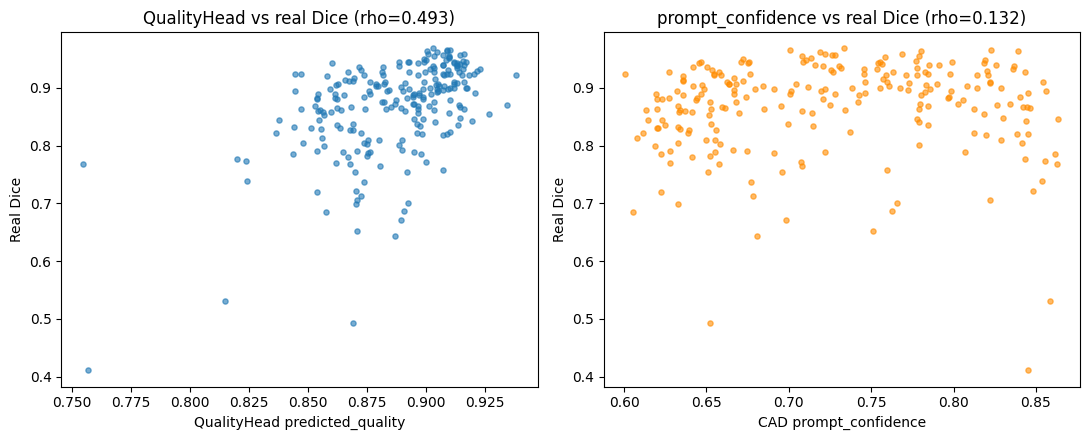

In [3]:
# @title
"""
test_quality_head_x2_shift03.py
=====================
Two things are evaluated here, not just one:
1. The usual Zoom / Zoom + shift segmentation scenarios (Dice/IoU/Pre/Rec/
   HD95/CBL), to confirm QualityHead training did not change segmentation
   quality versus the stage 1 x2/shift0.3 winner (it should not be able to,
   since QualityHead's inputs are detached, but this checks it empirically).
2. Whether the two no-GT confidence signals available on this checkpoint,
   QualityHead's predicted_quality and the free CAD prompt_confidence gate,
   actually correlate with real per-sample Dice on the test set (Spearman
   correlation). This is the "Validating the signals" step from
   Research/03_uncertainty_confidence/README.md: neither signal is worth
   using at inference until this number is checked.

Usage:
    python test_quality_head_x2_shift03.py
"""

import os
import sys
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import spearmanr

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CONFIGURATION - edit here
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_center_zoom_x2_qhead_512_best.pth"
IMG_SIZE           = 512
BATCH_SIZE         = 4
USE_ENCODER_PROMPT = True   # must match the training config above

SCALE_FACTOR = 2.0
SHIFT_RATIO  = 0.3

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"


# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

# =========================================================
# SINGLE-SCENARIO SEGMENTATION EVALUATION (sanity check: unchanged vs stage 1)
# =========================================================

def run_eval(model: torch.nn.Module, prompt_mode: str, **ds_kwargs) -> dict:
    ds = PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
        **ds_kwargs,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            preds   = (torch.sigmoid(model(images, prompts)) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()
                gm = masks[b, 0].cpu().numpy()
                pm = extract_lcc(pm)

                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()

                all_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                all_iou.append( (tp + smooth) / (tp + fp + fn + smooth))
                all_pre.append( (tp + smooth) / (tp + fp + smooth))
                all_rec.append( (tp + smooth) / (tp + fn + smooth))
                all_hd95.append(calc_hd95(pm.astype(bool), gm.astype(bool)))

                cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
                if cbl is not None:
                    all_cbl.append(cbl)

    return {
        'dice': np.mean(all_dice),
        'iou':  np.mean(all_iou),
        'pre':  np.mean(all_pre),
        'rec':  np.mean(all_rec),
        'hd95': np.mean(all_hd95),
        'cbl':  np.mean(all_cbl) if all_cbl else 0.0,
        'n':    len(all_dice),
    }

def evaluate_all(model: torch.nn.Module) -> dict:
    print("\n" + "=" * 72)
    print(f"  SEGMENTATION SANITY CHECK  |  center-zoom x{SCALE_FACTOR:g} + QualityHead")
    print("=" * 72)

    scenarios = {
        'Zoom (center_zoom)':          dict(prompt_mode='center_zoom', scale_factor=SCALE_FACTOR),
        'Zoom + shift (center_shift)': dict(prompt_mode='center_shift', scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO),
    }

    results = {}
    for name, kwargs in scenarios.items():
        results[name] = run_eval(model, **kwargs)
        print(f"  [{name}]  {results[name]['n']} samples, completed.")

    header = (f"\n{'Scenario':<30} {'Dice↑':>7} {'IoU↑':>7} "
              f"{'Pre↑':>7} {'Rec↑':>7} {'HD95↓':>8} {'CBL↑':>7} {'N':>5}")
    print(header)
    print("-" * 82)
    for name, r in results.items():
        print(f"{name:<30} {r['dice']:>7.4f} {r['iou']:>7.4f} "
              f"{r['pre']:>7.4f} {r['rec']:>7.4f} "
              f"{r['hd95']:>8.2f} {r['cbl']:>7.4f} {r['n']:>5}")
    return results

# =========================================================
# CONFIDENCE-SIGNAL VALIDATION: does predicted_quality / prompt_confidence
# actually track real per-sample Dice? Uses GT only to compute the real
# Dice for this check; the signals themselves need no GT to compute.
# =========================================================

def evaluate_confidence_signals(model: torch.nn.Module, prompt_mode: str, **ds_kwargs) -> dict:
    ds = PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
        **ds_kwargs,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    real_dice, pred_quality, prompt_conf = [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)

            logits, p_conf, p_quality = model(
                images, prompts, return_confidence=True, return_quality=True)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()
                gm = masks[b, 0].cpu().numpy()
                pm = extract_lcc(pm)
                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()
                real_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                pred_quality.append(p_quality[b].item())
                prompt_conf.append(p_conf[b].item())

    real_dice, pred_quality, prompt_conf = map(np.array, (real_dice, pred_quality, prompt_conf))
    rho_quality, p_quality_val = spearmanr(pred_quality, real_dice)
    rho_prompt,  p_prompt_val  = spearmanr(prompt_conf, real_dice)

    print("\n" + "=" * 72)
    print(f"  CONFIDENCE-SIGNAL VALIDATION  |  {prompt_mode}  |  N={len(real_dice)}")
    print("=" * 72)
    print(f"  QualityHead predicted_quality vs real Dice: Spearman rho={rho_quality:.4f} (p={p_quality_val:.4g})")
    print(f"  CAD prompt_confidence vs real Dice:          Spearman rho={rho_prompt:.4f} (p={p_prompt_val:.4g})")
    print("  rho close to 0 or negative means the signal does NOT track real quality; do not rely on it.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(pred_quality, real_dice, s=14, alpha=0.6)
    axes[0].set_xlabel("QualityHead predicted_quality"); axes[0].set_ylabel("Real Dice")
    axes[0].set_title(f"QualityHead vs real Dice (rho={rho_quality:.3f})")
    axes[1].scatter(prompt_conf, real_dice, s=14, alpha=0.6, color="darkorange")
    axes[1].set_xlabel("CAD prompt_confidence"); axes[1].set_ylabel("Real Dice")
    axes[1].set_title(f"prompt_confidence vs real Dice (rho={rho_prompt:.3f})")
    plt.tight_layout()
    plt.show()

    return dict(rho_quality=rho_quality, rho_prompt=rho_prompt,
                real_dice=real_dice, pred_quality=pred_quality, prompt_conf=prompt_conf)

# =========================================================
# LOAD MODEL
# =========================================================
model = PGA_UNet(use_encoder_prompt=USE_ENCODER_PROMPT, use_quality_head=True).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

# =========================================================
# 1) SEGMENTATION SANITY CHECK
# =========================================================
seg_results = evaluate_all(model)

# =========================================================
# 2) CONFIDENCE-SIGNAL VALIDATION (Zoom condition, the primary one)
# =========================================================
confidence_results = evaluate_confidence_signals(
    model, prompt_mode='center_zoom', scale_factor=SCALE_FACTOR)
